### Term-Document Matrix (Term Frequency)

Example:

**Document 1:** "Information retrieval is the science of search. Information is key."

**Document 2:** "A web search engine uses indexing for search."

**Document 3:** "A web search engine is used for information retrieval."

**Document 4:** "Indexing a database makes information in the database accessible."

**Keywords (terms):** information retrieval search engine web database indexing

> **Note:** In natural language processing, in extracting the keywords, we filter out generic words ("stop words"), like "a", "is", "of", and "the", before building the matrix because they don't carry meaningful search intent. Also, we only use the stem (no "s" for plurals).

In the term-document matrix, rows represent the unique vocabulary (terms) across the corpus, and columns represent the individual documents. The cell values indicate how many times a given term appears in a specific document.
The entries in a table like this are then naturally represented by an 7 x 4 matrix T (because each column is a vector in $\mathbb{R}^7$ and there are four columns).

(In modern information retrieval systems, these raw counts are typically mathematically weighted using.)

**Document 1**
> "Information retrieval is the science of search. Information is key."
* *(Counts: information: 2, retrieval: 1, search: 1)*

**Document 2**
> "A web search engine uses indexing for search."
* *(Counts: search: 2, engine: 1, web: 1, indexing: 1)*

**Document 3**
> "A web search engine is used for information retrieval."
* *(Counts: information: 1, retrieval: 1, search: 1, engine: 1, web: 1)*

| Term | Doc 1 | Doc 2 | Doc 3 | Doc 4 |
|:---|:---:|:---:|:---:|:---:|
| **information** | 2 | 0 | 1 | 1 |
| **retrieval** | 1 | 0 | 1 | 0 |
| **search** | 1 | 2 | 1 | 0 |
| **engine** | 0 | 1 | 1 | 0 |
| **web** | 0 | 1 | 1 | 0 |
| **database** | 0 | 0 | 0 | 2 |
| **indexing** | 0 | 1 | 0 | 1 |

$$T = \begin{bmatrix}
2 & 0 & 1 & 1 \\
1 & 0 & 1 & 0 \\
1 & 2 & 1 & 0 \\
0 & 1 & 1 & 0 \\
0 & 1 & 1 & 0 \\
0 & 0 & 0 & 2 \\
0 & 1 & 0 & 1
\end{bmatrix}$$

> **Note:** Rows represent the unique vocabulary (terms) across the corpus, and columns represent the individual documents. Cell values indicate how many times a given term appears in a specific document.

> **Note:** For dimensionality reduction, we curate the vocabulary to focus only on a specific cluster of related terms (in this case, search engine terminology). In real-world systems, stop word lists are often expanded to include highly common verbs and adjectives like *"use"*, and *"make"*.
Because these words appear in almost every context across the English language, they carry very little **search intent**. For example, if you search for "how to *use* a database," the word "database" is highly informative, while "use" is mostly noise. For domain relevance, when building a search index for a specific domain, you may filter out terms that don't belong to the core subject matter.
* Words like **"information"**, **"retrieval"**, **"search"**, and **"database"** are highly relevant technical nouns.
* Words like **"science"** and **"accessible"** might be considered peripheral to the core topic of the corpus and filtered out to save computational power and storage space.

> **Real-World Note:** If this were an unfiltered, production-level system, terms like "science" and "accessible" *would* actually be included in the matrix. They would just receive very low weights.

### How a Query Works in a Term-Document Matrix

In a term-document matrix, a search query is simply treated as a brand new "document." The system converts your query into a vector (a column of numbers) and mathematically compares it against all the existing document vectors to find the closest match.

$$q = \begin{bmatrix}
0 \\
0 \\
1 \\
1 \\
0 \\
0 \\
0
\end{bmatrix}$$

Here is exactly how the math works step-by-step, using the query **"search engine"** against our matrix.

#### 1. Vectorize the Query
First, the system creates a new column for the query, counting the term frequencies just like it did for the documents.

| Term | Doc 1 | Doc 2 | Doc 3 | Doc 4 | **Query: "search engine"** |
|:---|:---:|:---:|:---:|:---:|:---:|
| **information** | 2 | 0 | 1 | 1 | **0** |
| **retrieval** | 1 | 0 | 1 | 0 | **0** |
| **search** | 1 | 2 | 1 | 0 | **1** |
| **engine** | 0 | 1 | 1 | 0 | **1** |
| **web** | 0 | 1 | 1 | 0 | **0** |
| **database** | 0 | 0 | 0 | 2 | **0** |
| **indexing** | 0 | 1 | 0 | 1 | **0** |

#### 2. Calculate Similarity (The Dot Product)
To find out which document is the best match, the system multiplies the query's values by a document's values, row by row, and adds them up. This is called the **dot product**.

Let's calculate the score for **Doc 2**:
*   *information*: 0 × 0 = 0
*   *retrieval*: 0 × 0 = 0
*   *search*: 1 × 2 = **2**
*   *engine*: 1 × 1 = **1**
*   *(all other terms equal 0)*
*   **Doc 2 Total Score = 3**

If we do this for all documents:
*   **Doc 1 Score:** (1×1 for "search") = **1**
*   **Doc 2 Score:** (1×2 for "search") + (1×1 for "engine") = **3**
*   **Doc 3 Score:** (1×1 for "search") + (1×1 for "engine") = **2**
*   **Doc 4 Score:** (No matching terms) = **0**

#### 3. Rank the Results
The system sorts the documents by their final scores in descending order and returns them to the user.

1.  **Doc 2** (Score: 3) — *Best match*
2.  **Doc 3** (Score: 2)
3.  **Doc 1** (Score: 1)
4.  **Doc 4** (Score: 0) — *Ignored/Filtered out*

> **Real-World Nuance:** While the dot product is the foundation, modern systems use a formula called **Cosine Similarity**. Cosine similarity factors in the *length* of the document. Without it, a massive 500-page document would naturally score higher than a highly relevant 1-page document simply because it contains more total words.

Here is the Python code to recreate the exact term-document matrix, process the query, and calculate the dot product scores.

This script uses Python's built-in text processing and `pandas` to format the matrix.

In [1]:
import pandas as pd
import numpy as np
import re

# Define the Corpus
documents = [
    "Information retrieval is the science of search. Information is key.",
    "A web search engine uses indexing for search.",
    "A web search engine is used for information retrieval.",
    "Indexing a database makes information in the database accessible."
]

# Force the specific vocabulary (to match above)
# If we didn't provide this, the tokenizer would extract ALL words (like "science", "makes", ...)
vocab = ['information', 'retrieval', 'search', 'engine', 'web', 'database', 'indexing']

# Build the Term-Document Matrix without requiring scikit-learn
def vectorize(text):
    words = re.findall(r"\b\w+\b", text.lower())
    return np.array([words.count(term) for term in vocab])

doc_matrix = np.array([vectorize(document) for document in documents])

# Scikit-learn outputs Documents as rows and Terms as columns.
# We transpose it (.T) to match our Term-Document format.
td_matrix = pd.DataFrame(
    doc_matrix.T,
    index=vocab,
    columns=['Doc 1', 'Doc 2', 'Doc 3', 'Doc 4']
)

print("--- Term-Document Matrix ---\n")
print(td_matrix)
print("\n" + "="*40 + "\n")

# Vectorize the Query
query = ["search engine"]
query_vector = vectorize(query[0])

print(f"--- Query Vector: '{query[0]}' ---\n")
print(pd.DataFrame({'Query': query_vector}, index=vocab))
print("\n" + "="*40 + "\n")

# Calculate Similarity (The Dot Product)
# np.dot multiplies the document matrix by the query vector row-by-row and sums them up
scores = np.dot(doc_matrix, query_vector)

# Rank and Display the Results
results = pd.DataFrame({
    'Document': ['Doc 1', 'Doc 2', 'Doc 3', 'Doc 4'],
    'Score': scores
})

# Sort descending to get the best matches at the top
ranked_results = results.sort_values(by='Score', ascending=False).reset_index(drop=True)

print("--- Final Search Results ---\n")
print(ranked_results)

--- Term-Document Matrix ---

             Doc 1  Doc 2  Doc 3  Doc 4
information      2      0      1      1
retrieval        1      0      1      0
search           1      2      1      0
engine           0      1      1      0
web              0      1      1      0
database         0      0      0      2
indexing         0      1      0      1


--- Query Vector: 'search engine' ---

             Query
information      0
retrieval        0
search           1
engine           1
web              0
database         0
indexing         0


--- Final Search Results ---

  Document  Score
0    Doc 2      3
1    Doc 3      2
2    Doc 1      1
3    Doc 4      0


The Scaled Dot-Product Attention mechanism is the core mathematical operation behind modern Transformer models (like GPT). It calculates how much "attention" a given Query should pay to various Keys, and uses those resulting probability scores to weight the Values. The operation is defined by:$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

For a given index i in a vector of inputs z, the softmax is:
$$\text{Softmax}(z_{i})=\frac{e^{z_{i}}}{\sum _{j=1}^{K}e^{z_{j}}}$$

where
$$\mathbf {z} =(z_{1},\dotsc ,z_{K})\in \mathbb {R} ^{K}$$

In [2]:
import numpy as np

def scaled_dot_product_attention(Q, K, V):
    """
    Core engine for Transformers.
    Computes attention weights and the resulting context vector.
    The model takes a Query and compares it against all Keys
    to determine relevant Value pairs to focus on.
    Args:
        Q: Query (What I'm looking for)
        K: Key (What information others have)
        V: Value (The actual content)

    Returns:
        output: The weighted sum of Values.
        attention_weights: The softmax probabilities indicating where the model "focused".
    """
    # d_k is the dimension of the key/query vectors
    d_k = Q.shape[-1]

    # MatMul: Calculate similarity scores (Q * K^T)
    # Compare Query against all Keys via Dot Product
    scores = np.matmul(Q, K.T) / np.sqrt(d_k)

    # Softmax: Turn scores into probabilities (weights 0 to 1)
    # This determines how much focus to put on each Value
    exp_scores = np.exp(scores - np.max(scores))
    attention_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)

    # MatMul: Apply weights to the Values
    output = np.matmul(attention_weights, V)

    return output, attention_weights

# Example: 3 words (AI, is, math) represented as 4D vectors
embeddings = np.array([
    [1.0, 0.0, 0.5, 0.1], # "AI"
    [0.1, 1.2, 0.0, 0.9], # "is"
    [0.4, 0.1, 1.5, 0.2]  # "math"
])

# Dimension 1: (Technical) High for AI, low for "is".
# Dimension 2: (verb-ness) High for "is", low for AI.
# Dimension 3: (Conceptual): High for AI/Math, low for functional words.
# Dimension 4: (Functional/Connective) High for "is".

# Self-Attention: A mechanism where each token in a sequence calculates its relationship to all other tokens to understand context
# For self-attention, Q, K, and V start from the same embeddings
context_vector, attention_matrix = scaled_dot_product_attention(embeddings, embeddings, embeddings)

# Attention Matrix: Generated by multiplying the Query and Key matrices, measuring pairwise similarities between tokens.
# Weighted Representation: The output is a weighted average of the input, creating a context-aware representation of each token.

print("Attention Matrix (Probabilities) (N x N) showing how words relate:")
print(attention_matrix.round(decimals=3))
print("\nWeighted Representation -- Final Context Vector (Weighted Values) (N x D) of each word:")
print(context_vector.round(decimals=3))



Attention Matrix (Probabilities) (N x N) showing how words relate:
[[0.393 0.23  0.376]
 [0.204 0.575 0.22 ]
 [0.28  0.185 0.534]]

Weighted Representation -- Final Context Vector (Weighted Values) (N x D) of each word:
[[0.567 0.314 0.761 0.322]
 [0.35  0.712 0.433 0.582]
 [0.513 0.276 0.942 0.302]]


Matrix Multiplication (np.matmul): This is the most expensive operation in AI. It calculates the "relatedness" between every word in your input simultaneously.


Scaling: To prevent the values from becoming too large, which helps the model learn more stably.


Softmax: Ensures all weights in a row sum to 1.0, effectively creating a probability distribution of "where the model should look".

In [3]:
import math
import numpy as np

# This cell originally used PyTorch. The NumPy version below keeps the example runnable
# in environments where torch is not installed.
def softmax(x, axis=-1):
    exp_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return exp_x / exp_x.sum(axis=axis, keepdims=True)

class SelfAttention:
    def __init__(self, embed_size):
        self.embed_size = embed_size
        rng = np.random.default_rng(42)
        self.query_layer = rng.normal(size=(embed_size, embed_size))
        self.key_layer = rng.normal(size=(embed_size, embed_size))
        self.value_layer = rng.normal(size=(embed_size, embed_size))

    def forward(self, x):
        Q = x @ self.query_layer
        K = x @ self.key_layer
        V = x @ self.value_layer
        scores = Q @ K.T / math.sqrt(self.embed_size)
        attention_weights = softmax(scores)
        contextualized_output = attention_weights @ V
        return contextualized_output, attention_weights

sentence = "i sat by the river bank"
vocab = {"<PAD>": 0, "i": 1, "sat": 2, "by": 3, "the": 4, "river": 5, "bank": 6}

token_ids = [vocab[word.lower()] for word in sentence.split()]
print(f"Token IDs: {token_ids}\n")

vocab_size = len(vocab)
embed_size = 16
rng = np.random.default_rng(7)
embedding_table = rng.normal(size=(vocab_size, embed_size))
raw_embeddings = embedding_table[token_ids]

attention_layer = SelfAttention(embed_size)
contextualized_words, weights = attention_layer.forward(raw_embeddings)

print("--- Attention Matrix ---")
bank_attention = weights[2, :]

for word, weight in zip(sentence.split(), bank_attention):
    print(f"{word:>8}: {weight:.4f}")

Token IDs: [1, 2, 3, 4, 5, 6]

--- Attention Matrix ---
       i: 0.0000
     sat: 0.0000
      by: 0.0001
     the: 0.4730
   river: 0.5248
    bank: 0.0021


###PageRank Example:

Consider a set of six web pages that are related via web links (outlinks and inlinks) according to the directed graph below.

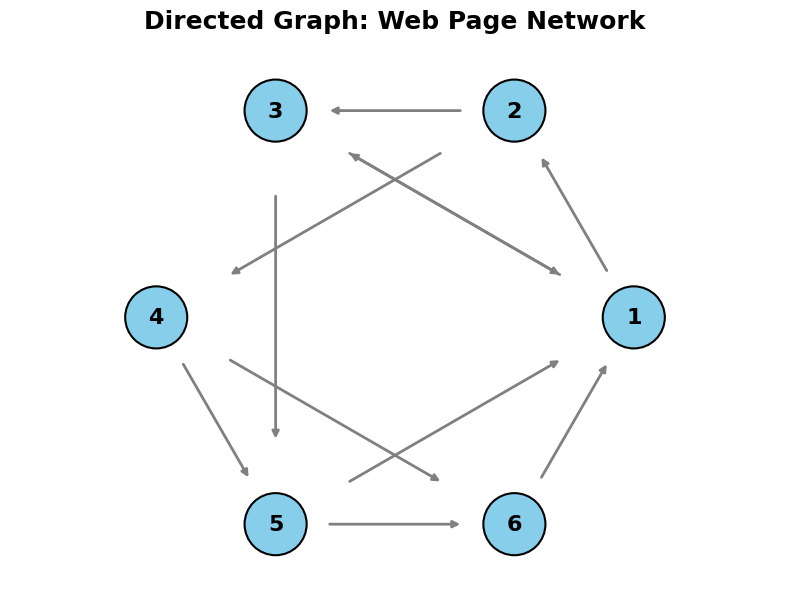

In [4]:
import numpy as np
import matplotlib.pyplot as plt

edges = [
    (1, 2), (1, 3),
    (2, 3), (2, 4),
    (3, 1), (3, 5),
    (4, 5), (4, 6),
    (5, 1), (5, 6),
    (6, 1)
]

nodes = np.arange(1, 7)
angles = np.linspace(0, 2*np.pi, len(nodes), endpoint=False)
pos = {node: np.array([np.cos(angle), np.sin(angle)]) for node, angle in zip(nodes, angles)}

plt.figure(figsize=(8, 6))
ax = plt.gca()

for start, end in edges:
    start_pos = pos[start]
    end_pos = pos[end]
    direction = end_pos - start_pos
    ax.annotate(
        "",
        xy=start_pos + 0.82*direction,
        xytext=start_pos + 0.18*direction,
        arrowprops=dict(arrowstyle="-|>", color="gray", lw=2, shrinkA=8, shrinkB=8)
    )

for node, (x, y) in pos.items():
    circle = plt.Circle((x, y), 0.13, color="skyblue", ec="black", lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(node), ha="center", va="center", fontsize=16, fontweight="bold", zorder=4)

plt.title("Directed Graph: Web Page Network", fontsize=18, fontweight="bold", pad=20)
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.show()

The
6 x 6 adjacency matrix $A$ for this graph has a nonzero value (unity) in element $A_j$ if there is a link from node (web page) $j$ to node $i$. The link graph matrix $L$ is found from the adjacency matrix by normalizing (each column) with respect to the number of outlinks so that each column sums to unity.


### Web Graph Structure

Consider a network of 6 web pages with the following directed links:
* **Page 1** links to: 2, 3
* **Page 2** links to: 3, 4
* **Page 3** links to: 1, 5
* **Page 4** links to: 5, 6
* **Page 5** links to: 1, 6
* **Page 6** links to: 1

---

### 1. Adjacency Matrix ($A$)
The adjacency matrix $A$ represents the raw unweighted connections. We define $A_{ij} = 1$ if there is a directed link **from** page $i$ (row) **to** page $j$ (column), and $0$ otherwise.

$$
A = \begin{bmatrix}
0 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 & 1 \\
1 & 0 & 0 & 0 & 0 & 1 \\
1 & 0 & 0 & 0 & 0 & 0
\end{bmatrix}
$$

---

### 2. Link Graph Matrix ($L$)
The link matrix $L$ (or transition probability matrix) is used in algorithms like PageRank. It is built by taking the transpose of the adjacency matrix and dividing each column by the number of outlinks from that page (its out-degree).

In this matrix, $L_{ij}$ represents the probability of moving **from** page $j$ (column) **to** page $i$ (row). Each column must sum to 1 (making it a column-stochastic matrix).

$$
L = \begin{bmatrix}
0 & 0 & 1/2 & 0 & 1/2 & 1 \\
1/2 & 0 & 0 & 0 & 0 & 0 \\
1/2 & 1/2 & 0 & 0 & 0 & 0 \\
0 & 1/2 & 0 & 0 & 0 & 0 \\
0 & 0 & 1/2 & 1/2 & 0 & 0 \\
0 & 0 & 0 & 1/2 & 1/2 & 0
\end{bmatrix}
$$

Quantifying the importance of web pages is related to an eigenvector of Link Graph Matrix $L$, which is most famously used as the mathematical foundation for Google’s original PageRank algorithm. It is used to calculate the relative "importance" or authority of every web page in a network. Matrix $L$ acts as a transition probability matrix: If a user is currently on Page A and clicks a random link, what is the probability they end up on Page B? Because we divided each column by the total number of outlinks, every column in $L$ sums exactly to 1. This means the matrix perfectly conserves probability — no web surfers are lost or created during a click. To find out which pages are the most important, a search engine simulates millions of users clicking links indefinitely. Instead of simulating actual users, this is done mathematically using **Matrix Multiplication**.

Start with a vector $v_0$ representing an equal probability of being on any of the 6 pages (e.g., $v_0 = [\frac{1}{6}, \frac{1}{6}, \frac{1}{6}, \frac{1}{6}, \frac{1}{6}, \frac{1}{6}]^T$). Multiply the link matrix $L$ by this vector to calculate where everyone is after one click:
$$v_1 = L \cdot v_0$$

Repeat this process over and over:
$$v_{t+1} = L \cdot v_t$$

Eventually, the vector stops changing. This final steady-state vector is the dominant eigenvector of matrix $L$ (with the corresponding eigenvector of $\lambda=1$). The values inside this final vector represent the ultimate PageRank score for each web page. If Page 1 ends up with a value of 0.35, it means a random surfer spends 35% of their time on Page 1, making it a highly authoritative page. Fixing Traps (The Google Matrix): In the real world, matrix $L$ has a fatal flaw: "Spider traps" (pages that only link to each other) and "Dead ends" (pages with no outlinks) will hoard all the probability, breaking the math. To fix this, the raw matrix $L$ is combined with a Damping Factor (usually $d = 0.85$). This simulates a user who gets bored 15% of the time and types a brand new URL into their browser instead of clicking a link on the page. This modified version of $L$ is known as the Google Matrix.

###Convolution

The convolution operation is the key component of any convolutional neural network. Convolution is the foundational mathematical operation used to determine the output of a Linear Time-Invariant (LTI) discrete-time system for any arbitrary input signal. If you know a system's response to a single, localized impulse, convolution allows you to compute its response to any complex, continuous stream of inputs. A linear time-invariant (LTI) system is a process or "black box" that takes an input signal and turns it into an output signal by following two core rules: linearity and time-invariance.

Because any complex input signal $x(t)$ can be broken down into an infinite sum of tiny, shifted impulse spikes, the total output $y(t)$ is just the sum of the system's responses to all those tiny spikes. This process of blending the input signal $x(t)$ with the impulse response $h(t)$ is called convolution. For continuous signals, convolution is calculated using an integral:

$$y(t)=\int _{-\infty }^{\infty }x(\tau )h(t-\tau )d\tau $$

If you are working with digital or discrete-time signals, the integral becomes a simple summation:

$$y[n]=\sum _{k=-\infty }^{\infty }x[k]h[n-k]$$

When transforming the signals out of the time domain into the frequency domain (using Fourier transforms, for example), the convolution turns into simple multiplication:

$$Y(s) = H(s) X(s)$$

where $X$ is a length-N vector, $Y$ is a length-M vector, and $H$ is an M x N matrix with elements $H_{ij} = h[i — j], 0<i-j<k, i=1,\dots,M, j=1,\dots,N$.


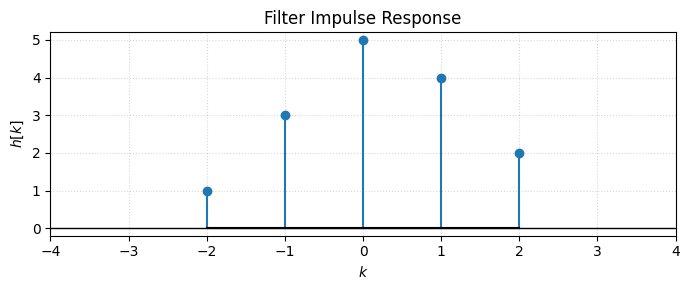

Az ('full') matrix shape:  (14, 10)
As ('same') matrix shape:  (10, 10)
Ac ('circ') matrix shape:  (10, 10)


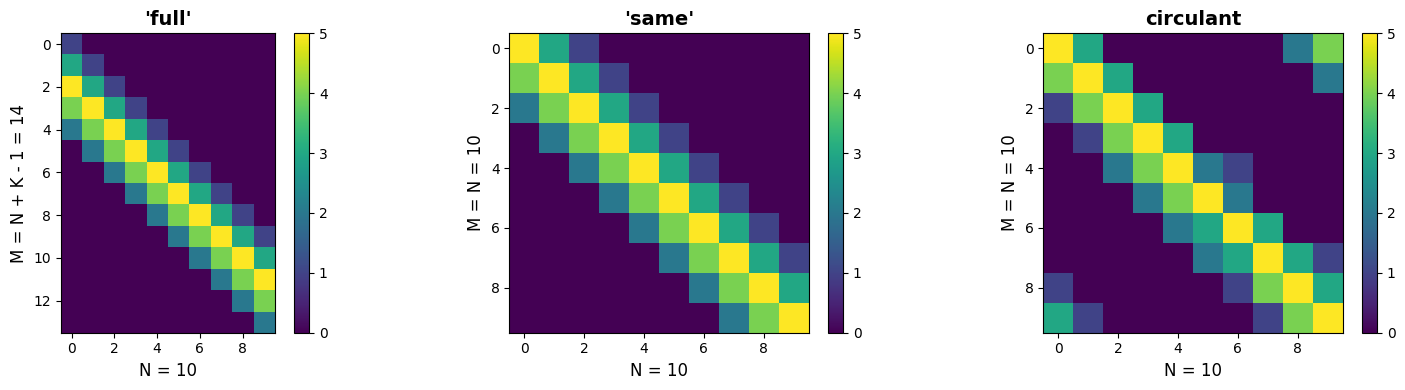

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# ==========================================
# Filter Definition
# ==========================================
psf = np.array([1, 3, 5, 4, 2])  # Filter impulse response h[k]
K = len(psf)
hp = (K - 1) // 2                # Half-width = 2
N = 10                           # Input signal length

# Plot impulse response h[k]
k_support = np.arange(-hp, hp + 1)
plt.figure(figsize=(7, 3))
plt.stem(k_support, psf, basefmt="k-")
plt.axhline(0, color='black', linewidth=1)
plt.xlim(-4, 4)
plt.ylim(-0.2, 5.2)
plt.xlabel(r"$k$")
plt.ylabel(r"$h[k]$")
plt.title("Filter Impulse Response")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Matrix Construction Helper
# ==========================================
def operator_to_matrix(operator_fn, input_dim):
    """
    Constructs an explicit matrix by passing standard basis vectors
    e_i through the linear operator function.
    """
    columns = []
    for i in range(input_dim):
        e_i = np.zeros(input_dim)
        e_i[i] = 1.0
        columns.append(operator_fn(e_i))
    return np.column_stack(columns).astype(int)

# ==========================================
# Convolution Matrices
# ==========================================

# 'full': Zero boundary conditions, size M = N + K - 1 = 14
Az = operator_to_matrix(lambda x: convolve(x, psf, mode='full'), N)

# 'circ': Periodic/circulant boundary conditions, size M = N = 10
def circular_conv(x, h, n):
    kernel_padded = np.zeros(n)
    kernel_padded[:hp + 1] = h[hp:]
    kernel_padded[-hp:] = h[:hp]
    return np.real(np.fft.ifft(np.fft.fft(x) * np.fft.fft(kernel_padded)))

Ac = operator_to_matrix(lambda x: circular_conv(x, psf, N), N)

# 'same': Matching input and output lengths, size M = N = 10
As = Az[hp : hp + N, :]

# 'valid': Overlap-only samples, size M = N - K + 1 = 6
#Av = Az[(K - 1) : N, :]

# Print dimensions
print(f"Az ('full') matrix shape:  {Az.shape}")
#print(f"Av ('valid') matrix shape: {Av.shape}")
print(f"As ('same') matrix shape:  {As.shape}")
print(f"Ac ('circ') matrix shape:  {Ac.shape}")

# ==========================================
# Heatmap Visualizations with Colorbars
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

matrix_specs = [
    (Az, "'full'", f"M = N + K - 1 = {Az.shape[0]}"),
    #(Av, "'valid'", f"M = N - K + 1 = {Av.shape[0]}"),
    (As, "'same'", f"M = N = {As.shape[0]}"),
    (Ac, "circulant", f"M = N = {Ac.shape[0]}")
]

# Set color limits to match max filter response (psf max is 5)
v_min, v_max = 0, 5

for ax, (matrix, title, ylabel) in zip(axes, matrix_specs):
    im = ax.imshow(matrix, cmap='viridis', aspect='equal', origin='upper', vmin=v_min, vmax=v_max)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("N = 10", fontsize=12)

    # Add colorbar matched to subplot height
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

###Example:

Input Signal ($x$): $x = \begin{bmatrix} 1 & 0 & 2 & 0 & 1 \end{bmatrix}^T$ ($N = 5$)

Impulse Response ($h$): $h = \begin{bmatrix} 1 & 3 & 5 & 4 & 2 \end{bmatrix}^T$ ($K = 5$, $hp = 2$)

The full convolution operator $A_{\text{full}}$ has dimension $M \times N = (N + K - 1) \times N = 9 \times 5$. Each column $j$ contains $h$ shifted down by $j$ positions with zero-padding:$$A_{\text{full}} = \begin{bmatrix} 1 & 0 & 0 & 0 & 0 \\ 3 & 1 & 0 & 0 & 0 \\ 5 & 3 & 1 & 0 & 0 \\ 4 & 5 & 3 & 1 & 0 \\ 2 & 4 & 5 & 3 & 1 \\ 0 & 2 & 4 & 5 & 3 \\ 0 & 0 & 2 & 4 & 5 \\ 0 & 0 & 0 & 2 & 4 \\ 0 & 0 & 0 & 0 & 2 \end{bmatrix}$$

Computing the linear combination of the columns weighted by $x$:$$y_{\text{full}} = \begin{bmatrix} 1 & 0 & 0 & 0 & 0 \\ 3 & 1 & 0 & 0 & 0 \\ 5 & 3 & 1 & 0 & 0 \\ 4 & 5 & 3 & 1 & 0 \\ 2 & 4 & 5 & 3 & 1 \\ 0 & 2 & 4 & 5 & 3 \\ 0 & 0 & 2 & 4 & 5 \\ 0 & 0 & 0 & 2 & 4 \\ 0 & 0 & 0 & 0 & 2 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \\ 2 \\ 0 \\ 1 \end{bmatrix}  = \begin{bmatrix} 1 \\ 3 \\ 7 \\ 10 \\ 13 \\ 11 \\ 9 \\ 4 \\ 2 \end{bmatrix}$$


In [6]:
import numpy as np
from scipy.signal import convolve

# Define inputs
x = np.array([1, 0, 2, 0, 1])  # Input signal (N = 5)
h = np.array([1, 3, 5, 4, 2])  # Filter impulse response (K = 5)

N = len(x)
K = len(h)
hp = (K - 1) // 2  # Half-width = 2

# Helper function to generate explicit matrices from linear operators
def operator_to_matrix(operator_fn, input_dim):
    columns = []
    for i in range(input_dim):
        e_i = np.zeros(input_dim)
        e_i[i] = 1.0
        columns.append(operator_fn(e_i))
    return np.column_stack(columns).astype(int)

# Circular convolution helper
def circular_conv(x_in, filter_h):
    n = len(x_in)
    kernel_padded = np.zeros(n)
    kernel_padded[:hp + 1] = filter_h[hp:]
    kernel_padded[-hp:] = filter_h[:hp]
    return np.real(np.fft.ifft(np.fft.fft(x_in) * np.fft.fft(kernel_padded)))

# Build explicit convolution matrices
A_full = operator_to_matrix(lambda v: convolve(v, h, mode='full'), N)
A_same = A_full[hp : hp + N, :]
A_valid = A_full[(K - 1) : N, :]
A_circ = operator_to_matrix(lambda v: circular_conv(v, h), N)

# 3. Perform Matrix-Vector Multiplication: y = A @ x
y_full = A_full @ x
y_circ = A_circ @ x

# 4. Display Results
print("=== Explicit Matrix A_full (9x5) ===")
print(A_full)

print("\n=== Computed Output Vectors (y = A @ x) ===")
print(f"Full  (M={len(y_full)}): {y_full}")
print(f"Circ  (M={len(y_circ)}): {y_circ}")

=== Explicit Matrix A_full (9x5) ===
[[1 0 0 0 0]
 [3 1 0 0 0]
 [5 3 1 0 0]
 [4 5 3 1 0]
 [2 4 5 3 1]
 [0 2 4 5 3]
 [0 0 2 4 5]
 [0 0 0 2 4]
 [0 0 0 0 2]]

=== Computed Output Vectors (y = A @ x) ===
Full  (M=9): [ 1  3  7 10 13 11  9  4  2]
Circ  (M=5): [11 12 13 12 10]


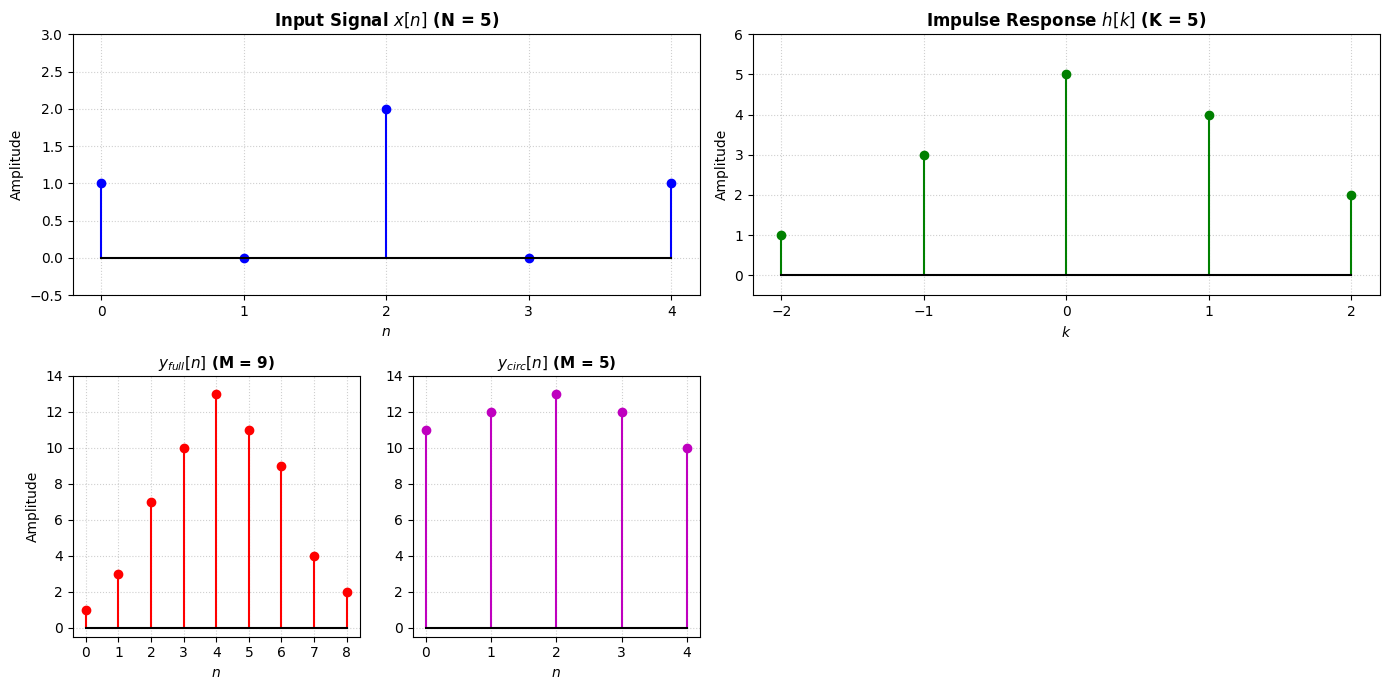

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# Define inputs
x = np.array([1, 0, 2, 0, 1])  # Input signal (N = 5)
h = np.array([1, 3, 5, 4, 2])  # Filter impulse response (K = 5)

N = len(x)
K = len(h)
hp = (K - 1) // 2  # Half-width = 2

# Helper function to generate explicit matrices from linear operators
def operator_to_matrix(operator_fn, input_dim):
    columns = []
    for i in range(input_dim):
        e_i = np.zeros(input_dim)
        e_i[i] = 1.0
        columns.append(operator_fn(e_i))
    return np.column_stack(columns).astype(int)

# Circular convolution helper
def circular_conv(x_in, filter_h):
    n = len(x_in)
    kernel_padded = np.zeros(n)
    kernel_padded[:hp + 1] = filter_h[hp:]
    kernel_padded[-hp:] = filter_h[:hp]
    return np.real(np.fft.ifft(np.fft.fft(x_in) * np.fft.fft(kernel_padded)))

# Build explicit convolution matrices
A_full = operator_to_matrix(lambda v: convolve(v, h, mode='full'), N)
A_circ = operator_to_matrix(lambda v: circular_conv(v, h), N)

# Perform Matrix-Vector Multiplication: y = A @ x
y_full = A_full @ x
y_same = A_same @ x
y_valid = A_valid @ x
y_circ = A_circ @ x

# Plot Signals (x, h, and y outputs)
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 4)

# Input Signal x[n]
ax_x = fig.add_subplot(gs[0, 0:2])
n_x = np.arange(N)
ax_x.stem(n_x, x, linefmt='b-', markerfmt='bo', basefmt='k-')
ax_x.set_title("Input Signal $x[n]$ (N = 5)", fontweight='bold', fontsize=12)
ax_x.set_xlabel("$n$")
ax_x.set_ylabel("Amplitude")
ax_x.set_xticks(n_x)
ax_x.set_ylim(-0.5, max(x) + 1)
ax_x.grid(True, linestyle=":", alpha=0.6)

# Impulse Response h[k]
ax_h = fig.add_subplot(gs[0, 2:4])
k_h = np.arange(-hp, hp + 1)
ax_h.stem(k_h, h, linefmt='g-', markerfmt='go', basefmt='k-')
ax_h.set_title("Impulse Response $h[k]$ (K = 5)", fontweight='bold', fontsize=12)
ax_h.set_xlabel("$k$")
ax_h.set_ylabel("Amplitude")
ax_h.set_xticks(k_h)
ax_h.set_ylim(-0.5, max(h) + 1)
ax_h.grid(True, linestyle=":", alpha=0.6)

# Outputs
outputs = [
    (y_full, "$y_{full}[n]$ (M = 9)", 'r', 'ro'),
    (y_circ, "$y_{circ}[n]$ (M = 5)", 'm', 'o')
]

for idx, (y_data, title, color, marker) in enumerate(outputs):
    ax = fig.add_subplot(gs[1, idx])
    n_y = np.arange(len(y_data))
    ax.stem(n_y, y_data, linefmt=f'{color}-', markerfmt=marker, basefmt='k-')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel("$n$")
    if idx == 0:
        ax.set_ylabel("Amplitude")
    ax.set_xticks(n_y)
    ax.set_ylim(-0.5, max(y_full) + 1)  # Fixed y-limits across outputs for direct comparison
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()